## **English Premier League Result Prediction**

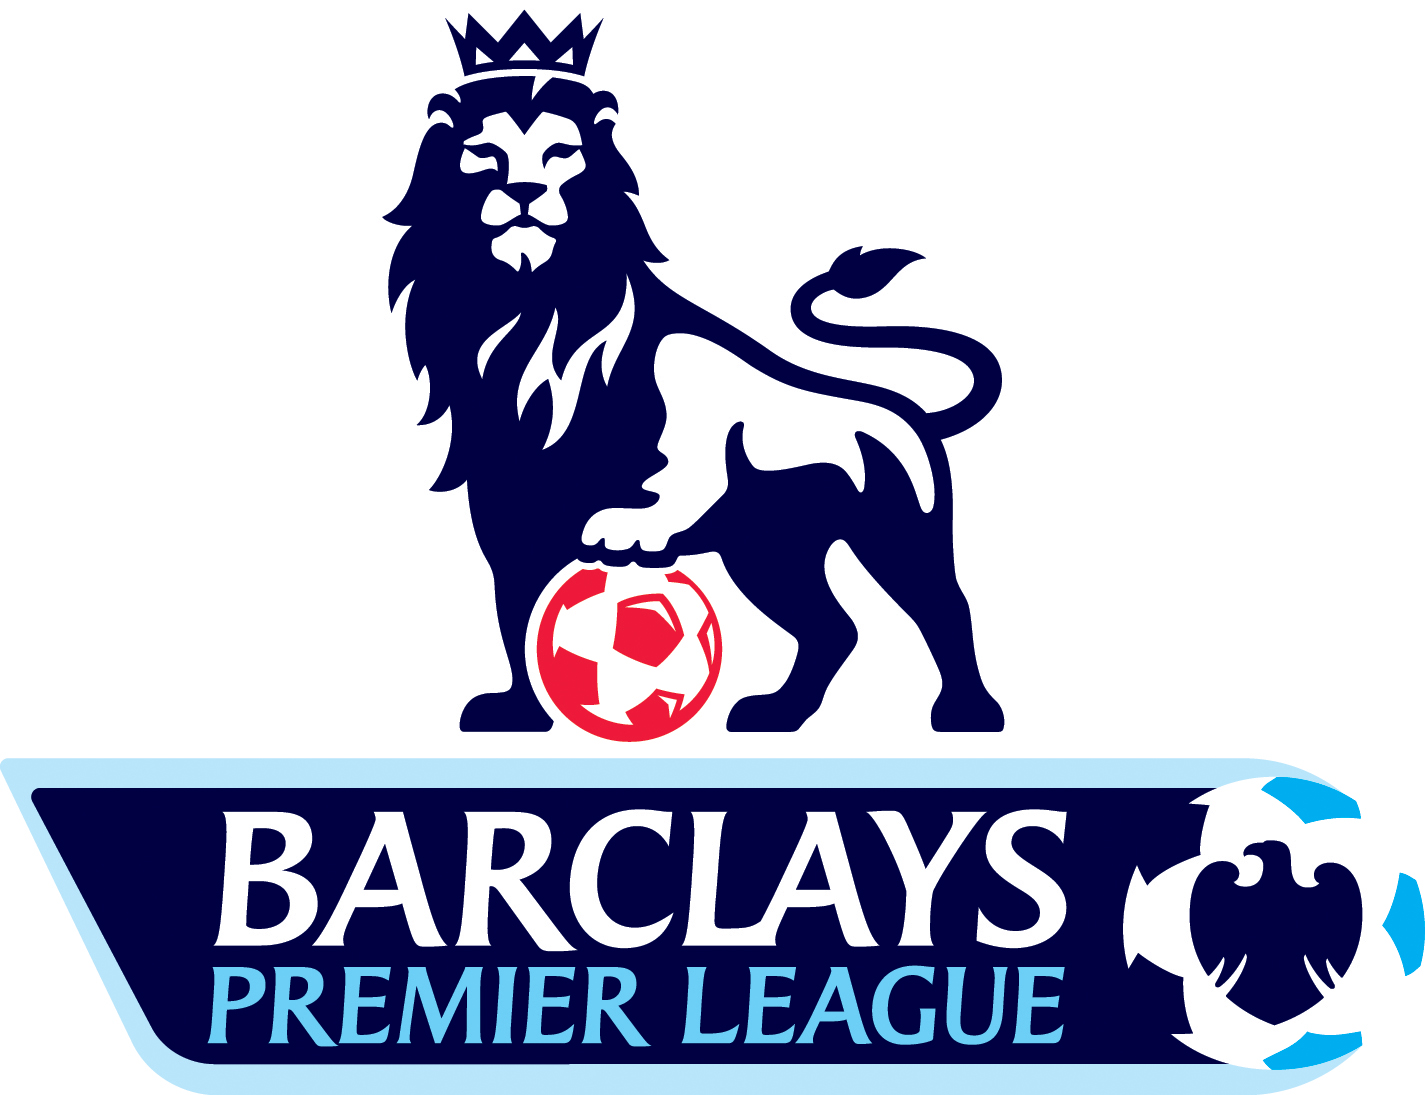

One of the top football leagues in the world is the English Premier League (EPL). Fans from all over the world eagerly anticipate each game since it contains some of the top teams and players. In addition to enjoying watching the sports, many individuals also love guessing the results of games. It is feasible to predict which side will win by looking at their recent performance, key players, and other elements. In this essay, we'll look at a few variables that can be used to forecast the outcomes of EPL games and talk about how you can utilise this knowledge to come up with your own predictions. A new level of excitement can be added to viewing the games if you learn how to anticipate the EPL results, whether you're a devoted follower or a casual viewer.
 
 In order to predict the result of upcoming matches an epl dataset is used and can be accessed from https://www.kaggle.com/datasets/evangower/premier-league-matches-19922022 this link. The dataset contains records from year 1993 to 2022 with eight coulmns and 11646 rows.

**Importing Basic Libraries**

In [3]:
import numpy as np

import pandas as pd

import warnings
warnings.filterwarnings("ignore")

**Loading of the Dataset**

In [4]:
eplmatches= pd.read_csv("eplmatches.csv")

**Accessing First Five Rows**

In [5]:
eplmatches.head()

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A


**Accessing Last Five Rows**

In [6]:
eplmatches.tail()

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
11641,2022,9,2021-10-23,Leeds United,1,1,Wolves,D
11642,2022,9,2021-10-23,Brighton,1,4,Manchester City,A
11643,2022,9,2021-10-24,West Ham,1,0,Tottenham,H
11644,2022,9,2021-10-24,Brentford,1,2,Leicester City,A
11645,2022,9,2021-10-24,Manchester Utd,0,5,Liverpool,A


**Accessing the Shape of the Dataset**

In [7]:
eplmatches.shape

(11646, 8)

**Describing the numerical Columns of The Dataset**

In [8]:
eplmatches.describe()

,Season_End_Year,Wk,HomeGoals,AwayGoals
count,11646.000000,11646.000000,11646.000000,11646.000000
mean,2007.214838,19.738022,1.520780,1.140048
std,8.781986,11.128955,1.302456,1.132243
min,1993.000000,1.000000,0.000000,0.000000
25%,2000.000000,10.000000,1.000000,0.000000
50%,2007.000000,20.000000,1.000000,1.000000
75%,2015.000000,29.000000,2.000000,2.000000
max,2022.000000,42.000000,9.000000,9.000000


**Accessing Column Names**

In [9]:
eplmatches.columns

Index(['Season_End_Year', 'Wk', 'Date', 'Home', 'HomeGoals', 'AwayGoals',
       'Away', 'FTR'],
      dtype='object')

**Accessing Column Data Types**

In [10]:
eplmatches.dtypes

Season_End_Year     int64
Wk                  int64
Date               object
Home               object
HomeGoals           int64
AwayGoals           int64
Away               object
FTR                object
dtype: object

**Changing Column Data Types**

In [11]:
data = eplmatches.astype({'Season_End_Year': 'int', 'Wk': 'int','Date':'str','Home':'str','HomeGoals':'int','AwayGoals':'int','Away':'str','FTR':'str'})

In [12]:
data['Date'] =  pd.to_datetime(data['Date'], format='%Y-%m-%d')

In [13]:
eplmatches.dtypes

Season_End_Year     int64
Wk                  int64
Date               object
Home               object
HomeGoals           int64
AwayGoals           int64
Away               object
FTR                object
dtype: object

**Accessing Unique Team Names**

In [14]:
Teams=pd.DataFrame()
Teams['Teams']=np.unique(data[['Home', 'Away']].values)

**Accessing unique valuees of Full Time Result(FTR)**

In [15]:
Winners=pd.DataFrame()
Winners['Winner']=np.unique(data[['FTR']].values)

**Displaying Unique Teams**

In [16]:
Teams.Teams

0             Arsenal
1         Aston Villa
2            Barnsley
3     Birmingham City
4           Blackburn
5           Blackpool
6              Bolton
7         Bournemouth
8       Bradford City
9           Brentford
10           Brighton
11            Burnley
12       Cardiff City
13       Charlton Ath
14            Chelsea
15      Coventry City
16     Crystal Palace
17       Derby County
18            Everton
19             Fulham
20       Huddersfield
21          Hull City
22       Ipswich Town
23       Leeds United
24     Leicester City
25          Liverpool
26    Manchester City
27     Manchester Utd
28      Middlesbrough
29      Newcastle Utd
30       Norwich City
31    Nott'ham Forest
32    Oldham Athletic
33         Portsmouth
34                QPR
35            Reading
36      Sheffield Utd
37     Sheffield Weds
38        Southampton
39         Stoke City
40         Sunderland
41       Swansea City
42       Swindon Town
43          Tottenham
44            Watford
45        

**Assigning code to each team**

In [17]:
Teams['TeamID'] = np.arange(Teams.shape[0])

**Displaying First Five Teams dataset**

In [18]:
Teams.head()

,Teams,TeamID
0,Arsenal,0
1,Aston Villa,1
2,Barnsley,2
3,Birmingham City,3
4,Blackburn,4


**Generating Home_encoded Column**

In [19]:
data['Home_encoded'] = data['Home'].map(Teams.set_index('Teams')['TeamID'])


**Generating Away_encoded Column**

In [20]:
data['Away_encoded'] = data['Away'].map(Teams.set_index('Teams')['TeamID'])

**Displaying First five rows**

In [21]:
eplmatches.head()

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A


**Assigning code to each type of result**

In [22]:
Winners['WinnerID'] = np.arange(Winners.shape[0])

**Creating FTR_encoded Column"

In [23]:
data['FTR_encoded'] = data['FTR'].map(Winners.set_index('Winner')['WinnerID'])

**Displaying Winners Dataframe**

In [24]:
Winners.head()

,Winner,WinnerID
0,A,0
1,D,1
2,H,2


**Displaying top five rows of modified data**

In [25]:
eplmatches.head()

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A


**Displaying a Scatter plot HomeGoals Vs Away Goals based on FTR**

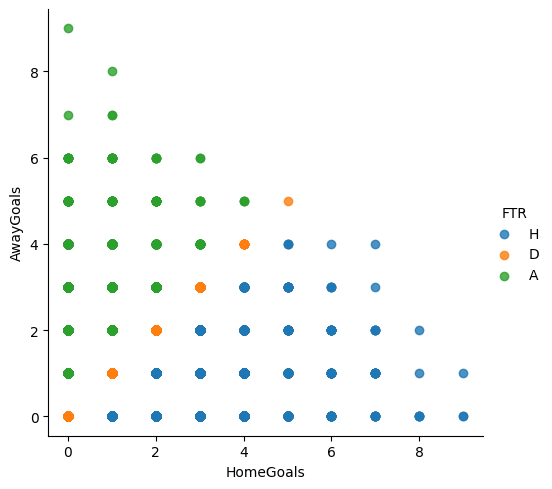

In [26]:
import matplotlib.pyplot as mpl
import seaborn as sb

sb.lmplot(x='HomeGoals',y='AwayGoals',data=data,fit_reg=False,hue='FTR')
mpl.show()

**Displaying FTR Valuses records distribution**

In [27]:
data['FTR'].value_counts()

H    5335
A    3301
D    3010
Name: FTR, dtype: int64

**Selecting desired input and target feature from Datasets**

In [28]:
X=data[['Season_End_Year', 'Wk','HomeGoals',	'AwayGoals', 'Home_encoded',	'Away_encoded']]
y=data[['FTR_encoded']]

**Creating two subsets training and test from given dataset**

In [29]:
from sklearn.model_selection import train_test_split
input_features_for_training,input_features_for_test,output_variable_for_train,output_variable_for_test = train_test_split(X,y,test_size=0.3,random_state=5, stratify=y)

**Creating trianing dataframe displying top five rows**

In [30]:
df_train=pd.DataFrame(data=np.c_[input_features_for_training,output_variable_for_train],columns=('Season_End_Year', 'Wk','HomeGoals',	'AwayGoals', 'Home_encoded',	'Away_encoded','FTR_encoded'))
df_train.head()

,Season_End_Year,Wk,HomeGoals,AwayGoals,Home_encoded,Away_encoded,FTR_encoded
0,2006,18,4,0,1,18,2
1,1996,30,1,1,31,29,1
2,2004,37,1,0,43,4,2
3,2009,17,2,2,25,21,1
4,2020,31,1,0,49,7,2


**Creating test dataframe displying top five rows**

In [31]:
df_test=pd.DataFrame(data=np.c_[input_features_for_test,output_variable_for_test],columns=('Season_End_Year', 'Wk', 'HomeGoals',	'AwayGoals', 'Home_encoded',	'Away_encoded','FTR_encoded'))
df_test.head()

,Season_End_Year,Wk,HomeGoals,AwayGoals,Home_encoded,Away_encoded,FTR_encoded
0,2003,29,1,0,4,26,2
1,2010,27,2,1,19,3,2
2,2010,28,1,0,6,49,2
3,2019,31,4,3,46,20,2
4,2006,25,2,0,29,33,2


**Displaying a Scatter plot HomeGoals Vs Away Goals based on FTR on training dataset**

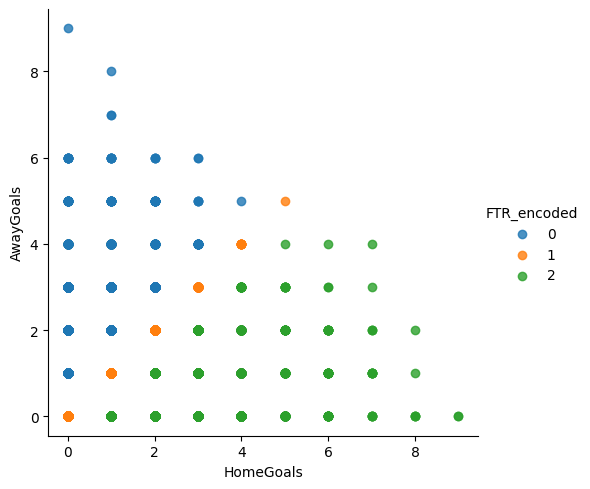

In [32]:
sb.lmplot(x='HomeGoals',y='AwayGoals',data=df_train,fit_reg=False,hue='FTR_encoded')
mpl.show()

In [33]:
df_train['FTR_encoded'].value_counts()

2    3734
0    2311
1    2107
Name: FTR_encoded, dtype: int64

**Displaying a Scatter plot HomeGoals Vs Away Goals based on FTR_encoded on test dataset**

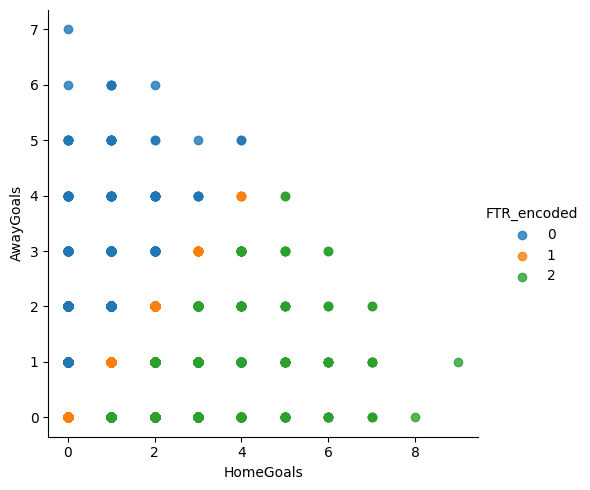

In [34]:
sb.lmplot(x='HomeGoals',y='AwayGoals',data=df_test,fit_reg=False,hue='FTR_encoded')
mpl.show()

In [35]:
df_test['FTR_encoded'].value_counts()

2    1601
0     990
1     903
Name: FTR_encoded, dtype: int64

# **Machine Learning Models**

**Importing various classification models**

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn import metrics 
from sklearn.metrics import confusion_matrix 

**Logistic Regression**

In [37]:
LR = LogisticRegression()
LR.fit(input_features_for_training,output_variable_for_train)
LR_predicted_y=LR.predict(input_features_for_test)
print('Logistic REgression :',metrics.accuracy_score(LR_predicted_y,output_variable_for_test))

Logistic REgression : 0.8832283915283343


**Decision Tree Model**

In [38]:
DTC_MDL=DecisionTreeClassifier()
DTC_MDL.fit(input_features_for_training,output_variable_for_train)
DTC_predicted_y=DTC_MDL.predict(input_features_for_test)
print('Decision Tree:',metrics.accuracy_score(DTC_predicted_y,output_variable_for_test))

Decision Tree: 0.9997137950772753


<Axes: >

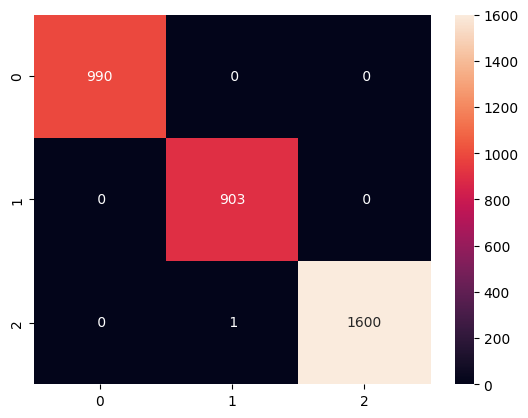

In [39]:
sb.heatmap(confusion_matrix(output_variable_for_test,DTC_predicted_y),annot=True,fmt='2.0f')

**Naive Bayes Model**

In [40]:
GNB_MDL=GaussianNB()
GNB_MDL.fit(input_features_for_training,output_variable_for_train)
NBpredicted_y=GNB_MDL.predict(input_features_for_test)
print('NaiveBayes :',metrics.accuracy_score(NBpredicted_y,output_variable_for_test))

NaiveBayes : 0.8949627933600458


<Axes: >

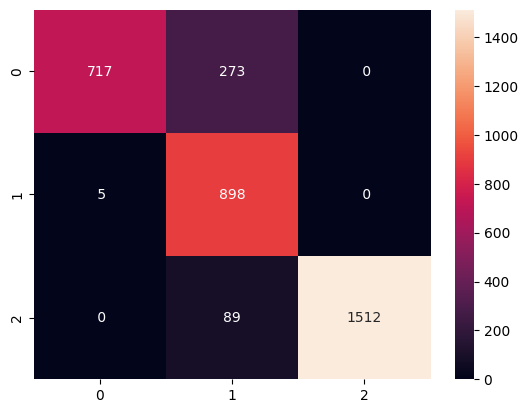

In [41]:
sb.heatmap(confusion_matrix(output_variable_for_test,NBpredicted_y),annot=True,fmt='2.0f')

**K Neighbors Model**

In [42]:
KNN_MDL=KNeighborsClassifier() 
KNN_MDL.fit(input_features_for_training,output_variable_for_train)
KNNpredicted_y=KNN_MDL.predict(input_features_for_test)
print('The accuracy of the KNN is',metrics.accuracy_score(KNNpredicted_y,output_variable_for_test))

The accuracy of the KNN is 0.4959931310818546


<Axes: >

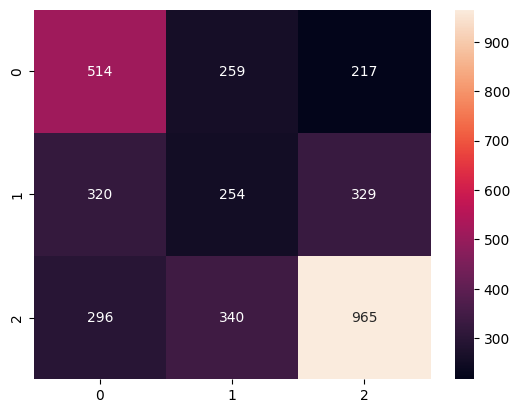

In [43]:
sb.heatmap(confusion_matrix(output_variable_for_test,KNNpredicted_y),annot=True,fmt='2.0f')

**Random Forest Model**

In [44]:
RFC_MDL=RandomForestClassifier(n_estimators=100)
RFC_MDL.fit(input_features_for_training,output_variable_for_train)
RFCpredicted_y=RFC_MDL.predict(input_features_for_test)
print('Random Forests :',metrics.accuracy_score(RFCpredicted_y,output_variable_for_test))

Random Forests : 0.9988551803091014


<Axes: >

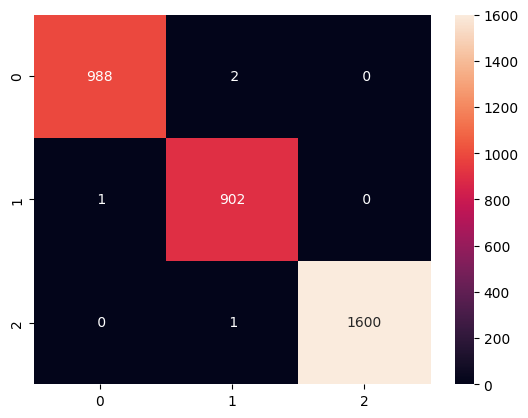

In [45]:
sb.heatmap(confusion_matrix(output_variable_for_test,RFCpredicted_y),annot=True,fmt='2.0f')

# **Conclusion**

The Decision tree out performs other classifers with accuracy of 0.9997. However, Random Forests stand second with accuracy score of 0.998
followed by naive bayes and logistic regression with 0.89 and 0.88 respectivly. KNN neighbors with accuracy 0.49 is worest model. So the result shows that Decision tree is the best model for this dataset. 


##References##

*   https://www.kaggle.com/datasets/evangower/premier-league-matches-19922022 (DataSet)
*   https://www.kaggle.com/code/ash316/eda-to-prediction-dietanic
(Code)
